## Comic Books Global Dataset - EDA & Analysis

###### 10,000 Comics | 2000-2026 | Manga * Manhwa * Marvel * DC * European

This notebook explores the **Comic Boooks Global Dataset** covering 10,0000 titles across 6 regions.

**What's Inside:**

* Comics by Contry & Region
* Rating Distribution & Topo Hihgest Rated
* Genre Breakdown
* Year Trend (200-2026)
* Award Winners
* Most Volumes
* Color Theme Analysis

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rudrakumargupta/comic-books-dataset-10000-entries")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'comic-books-dataset-10000-entries' dataset.
Path to dataset files: /kaggle/input/comic-books-dataset-10000-entries


In [8]:
import pandas as pd
import os, glob
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#14141f',
    'axes.edgecolor':   '#2a2a3a',
    'axes.labelcolor':  '#ccccdd',
    'xtick.color':      '#888899',
    'ytick.color':      '#888899',
    'text.color':       '#eeeeee',
    'grid.color':       '#1e1e2e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',

})

COLORS = ['#FFD700','#E63946','#00B4D8','#57EE9A','#C77DFF',
          '#FF6B6B','#48CAE4','#F4A261','#2EC4B6','#FF9F1C']

# List files in the downloaded dataset directory to find the CSV file
files_in_dataset = os.listdir(path)
csv_file_name = [f for f in files_in_dataset if f.endswith('.csv')][0]
full_csv_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_csv_path)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (10000, 17)


,comic_id,Title,Writer,Artist,Studio/Publisher,Release Year,Format,Theme (Color Style),Genre,Country of Origin,Page Count,Rating (out of 10),Status,Language,Age Rating,Awards,Volume Count
0,CMC-00001,Tiger of Zero,Gintoki Sakata,Gintoki Sakata,Shogakukan (Viz Media),2001,Tankobon,Full Color (Special Edition),Shoujo / Romance,Japan,890,8.0,Ongoing,Japanese,Mature,NaN,13
1,CMC-00002,Twisted Claw,Fumi Takahashi,Mika Sasaki,Shogakukan (Viz Media),2015,Tankobon,Black & White,Action / Historical,Japan,2850,8.3,Completed,Japanese,Mature,NaN,12
2,CMC-00003,Jean Grey: Rebirth,Chip Zdarsky,Bendis,Marvel Comics,2016,Graphic Novel,Full Color,Superhero / Thriller,USA,350,7.8,Ongoing,English,Teen+,Japan Media Arts Award Winner,13


In [9]:
print('=== DATASET OVERVIEW ===')
print(f'Total comics       : {len(df):,}')
print(f'Countries covered  : {df["Country of Origin"].nunique()}')
print(f'Unique genres      : {df["Genre"].nunique()}')
print(f'Year range         : {df["Release Year"].min()} – {df["Release Year"].max()}')
print(f'Average rating     : {df["Rating (out of 10)"].mean():.2f} / 10')
print(f'Highest rating     : {df["Rating (out of 10)"].max()}')
print(f'Total page count   : {df["Page Count"].sum():,.0f} pages')
print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0]}')
print('\nStatus breakdown:')
print(df['Status'].value_counts())

=== DATASET OVERVIEW ===
Total comics       : 10,000
Countries covered  : 21
Unique genres      : 105
Year range         : 2000 – 2026
Average rating     : 8.06 / 10
Highest rating     : 9.9
Total page count   : 22,328,712 pages

Missing values:
Awards    6016
dtype: int64

Status breakdown:
Status
Completed    5005
Ongoing      3820
Hiatus        741
Cancelled     434
Name: count, dtype: int64


#### Section 1 - Comics by Country & Top 10 Highest Rated

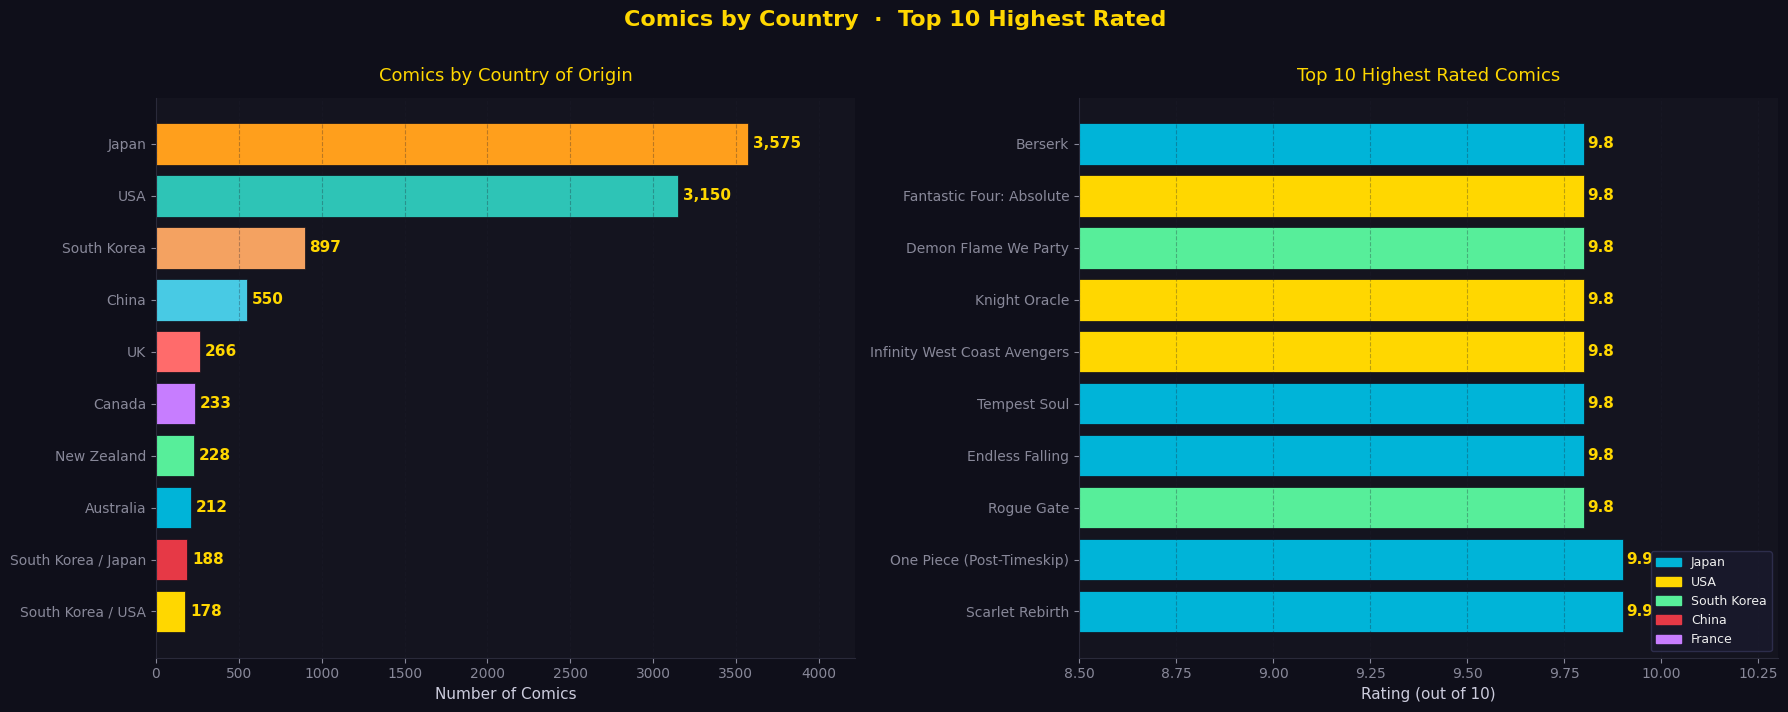

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Comics by Country  ·  Top 10 Highest Rated',
             fontsize=16, fontweight='bold', color='#FFD700', y=1.01)

# ── LEFT: Comics by Country (top 10) ──────────────────────────────────────
ax1 = axes[0]
country_counts = df['Country of Origin'].value_counts().head(10)
bars = ax1.barh(country_counts.index[::-1], country_counts.values[::-1],
                color=COLORS[:10], edgecolor='#0f0f1a', linewidth=0.5)
for bar, val in zip(bars, country_counts.values[::-1]):
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=11, color='#FFD700', fontweight='bold')
ax1.set_title('Comics by Country of Origin', fontsize=13, color='#FFD700', pad=12)
ax1.set_xlabel('Number of Comics', fontsize=11)
ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim(0, country_counts.max() * 1.18)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── RIGHT: Top 10 Highest Rated ────────────────────────────────────────────
ax2 = axes[1]
top10 = df.nlargest(10, 'Rating (out of 10)')[['Title','Rating (out of 10)','Country of Origin']].reset_index(drop=True)
colors_map = {'Japan':'#00B4D8','USA':'#FFD700','South Korea':'#57EE9A',
              'China':'#E63946','France':'#C77DFF'}
bar_colors = [colors_map.get(c, '#FF6B6B') for c in top10['Country of Origin']]
bars2 = ax2.barh(range(len(top10)), top10['Rating (out of 10)'],
                 color=bar_colors, edgecolor='#0f0f1a', linewidth=0.5)
ax2.set_yticks(range(len(top10)))
ax2.set_yticklabels([t[:28] for t in top10['Title']], fontsize=10)
for i, (bar, rating) in enumerate(zip(bars2, top10['Rating (out of 10)'])):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{rating}', va='center', fontsize=11, color='#FFD700', fontweight='bold')
ax2.set_title('Top 10 Highest Rated Comics', fontsize=13, color='#FFD700', pad=12)
ax2.set_xlabel('Rating (out of 10)', fontsize=11)
ax2.set_xlim(8.5, 10.3)
ax2.grid(axis='x', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
legend_patches = [mpatches.Patch(color=v, label=k) for k,v in colors_map.items()]
ax2.legend(handles=legend_patches, loc='lower right', fontsize=9,
           facecolor='#1a1a2e', edgecolor='#333355')

plt.tight_layout()
plt.savefig('section1_country_ratings.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

#### Section 2 - Year Trend (2000-2026) & Status Breakdown

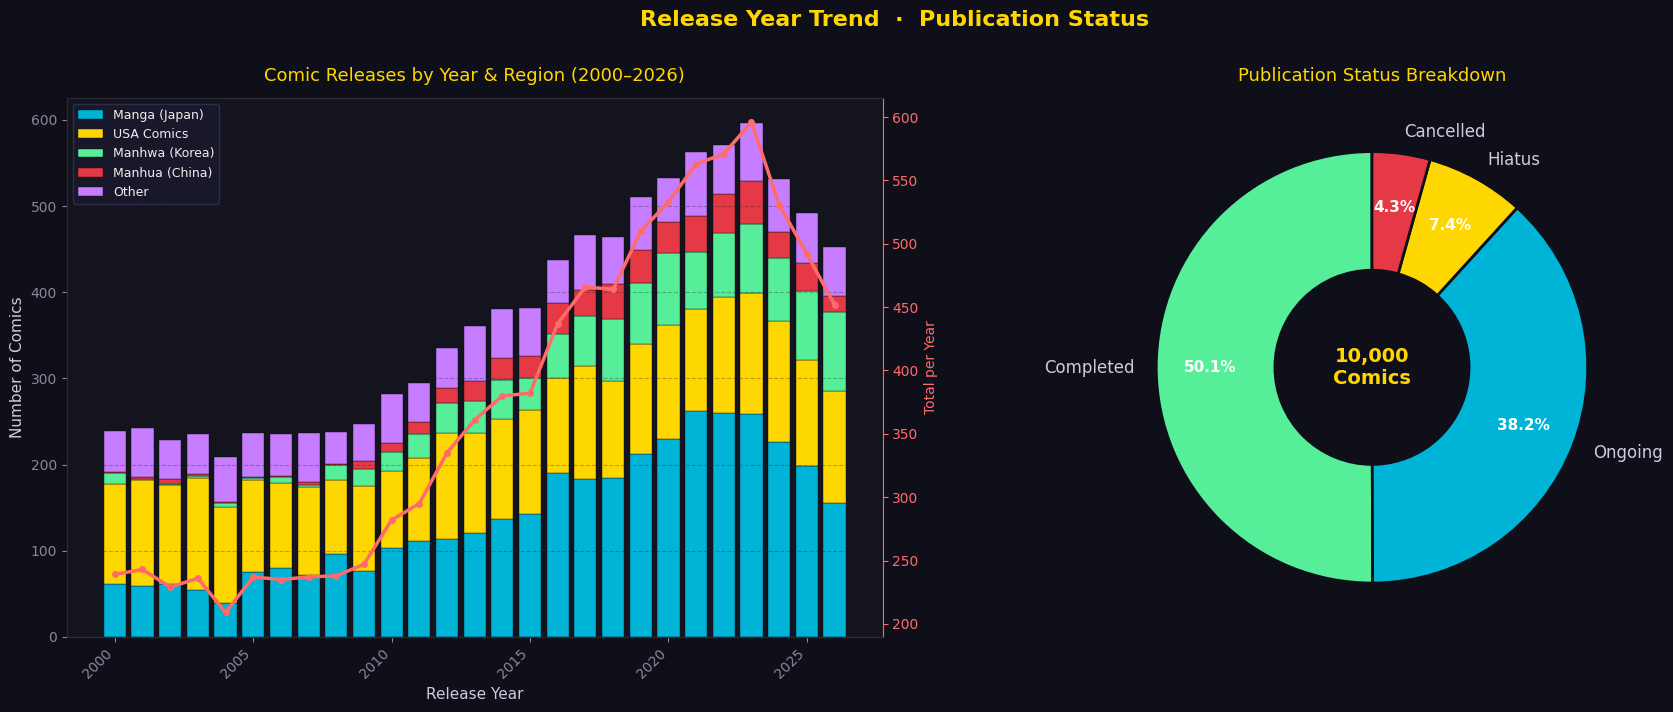

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Release Year Trend  ·  Publication Status',
             fontsize=16, fontweight='bold', color='#FFD700', y=1.01)

# ── LEFT: Year trend stacked by region ────────────────────────────────────
ax1 = axes[0]
region_map = {
    'Japan': 'Manga (Japan)',
    'South Korea': 'Manhwa (Korea)',
    'China': 'Manhua (China)',
    'USA': 'USA Comics',
}
df['Region'] = df['Country of Origin'].apply(
    lambda x: next((v for k,v in region_map.items() if k in str(x)), 'Other'))
year_region = df.groupby(['Release Year','Region']).size().unstack(fill_value=0)
region_colors = {'Manga (Japan)':'#00B4D8','USA Comics':'#FFD700',
                 'Manhwa (Korea)':'#57EE9A','Manhua (China)':'#E63946','Other':'#C77DFF'}
cols_order = [c for c in region_colors if c in year_region.columns]
bottom = np.zeros(len(year_region))
for col in cols_order:
    vals = year_region[col].values
    ax1.bar(year_region.index, vals, bottom=bottom,
            color=region_colors[col], label=col, width=0.8, edgecolor='#0f0f1a', linewidth=0.3)
    bottom += vals
# trend line
yearly_total = df.groupby('Release Year').size()
ax1_twin = ax1.twinx()
ax1_twin.plot(yearly_total.index, yearly_total.values, color='#FF6B6B',
              linewidth=2.5, marker='o', markersize=4, label='Total')
ax1_twin.set_ylabel('Total per Year', color='#FF6B6B', fontsize=10)
ax1_twin.tick_params(colors='#FF6B6B')
ax1_twin.spines['right'].set_color('#FF6B6B')
ax1.set_title('Comic Releases by Year & Region (2000–2026)', fontsize=13, color='#FFD700', pad=12)
ax1.set_xlabel('Release Year', fontsize=11)
ax1.set_ylabel('Number of Comics', fontsize=11)
ax1.legend(loc='upper left', fontsize=9, facecolor='#1a1a2e', edgecolor='#333355')
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ── RIGHT: Status donut ────────────────────────────────────────────────────
ax2 = axes[1]
status_counts = df['Status'].value_counts()
status_colors = ['#57EE9A','#00B4D8','#FFD700','#E63946']
wedges, texts, autotexts = ax2.pie(
    status_counts.values,
    labels=status_counts.index,
    colors=status_colors[:len(status_counts)],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width':0.55, 'edgecolor':'#0f0f1a', 'linewidth':2}
)
for text in texts: text.set_color('#ccccdd'); text.set_fontsize(12)
for autotext in autotexts: autotext.set_color('#ffffff'); autotext.set_fontsize(11); autotext.set_fontweight('bold')
ax2.set_title('Publication Status Breakdown', fontsize=13, color='#FFD700', pad=12)
# center text
ax2.text(0, 0, f'{len(df):,}\nComics', ha='center', va='center',
         fontsize=14, fontweight='bold', color='#FFD700')

plt.tight_layout()
plt.savefig('section2_year_status.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

#### Section 3 - Top Genres & Rating Distribution

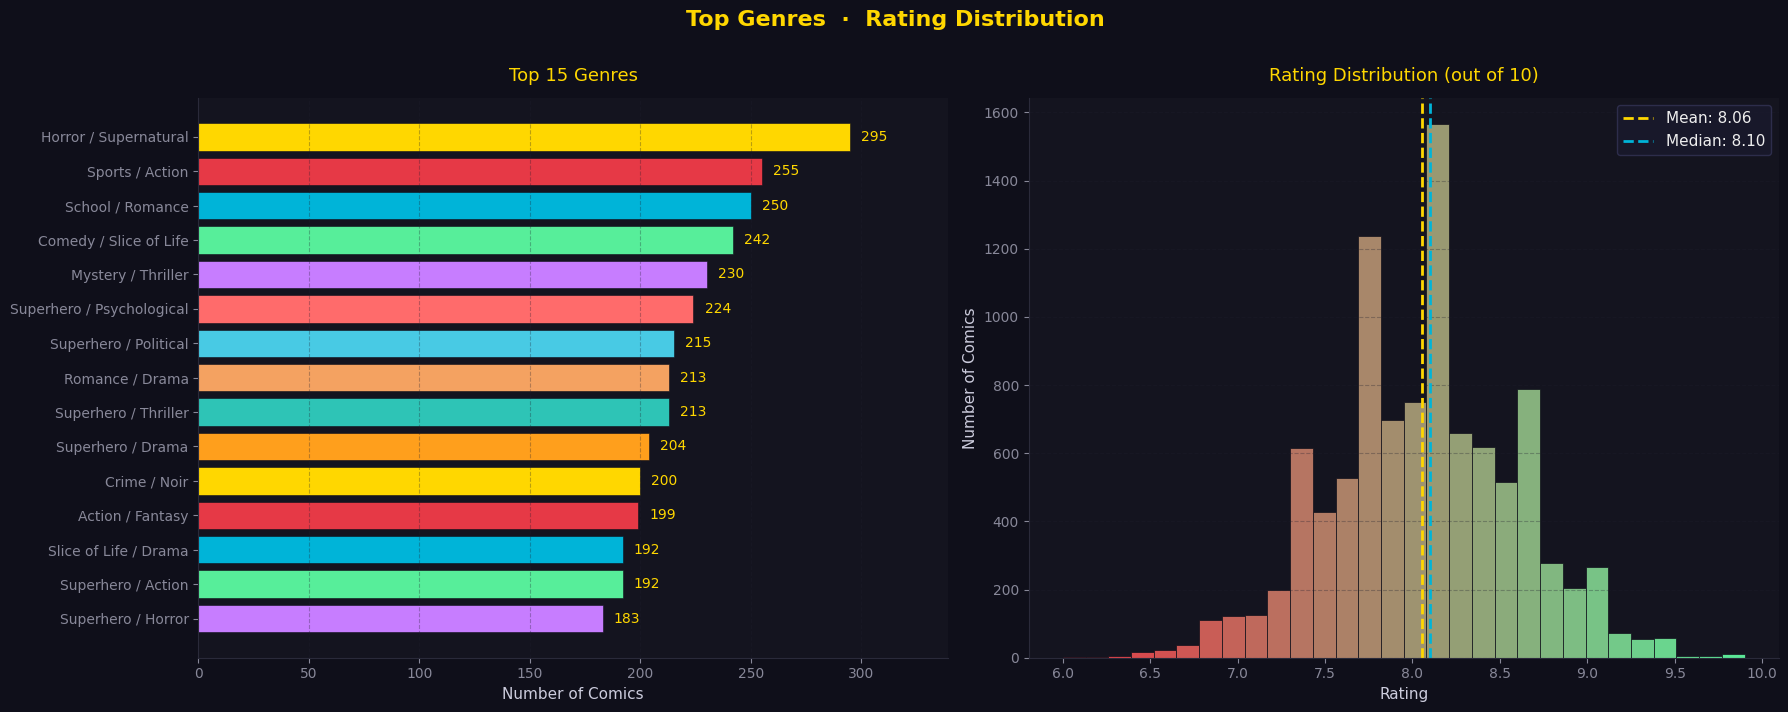

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Top Genres  ·  Rating Distribution',
             fontsize=16, fontweight='bold', color='#FFD700', y=1.01)

# ── LEFT: Top 15 genres ────────────────────────────────────────────────────
ax1 = axes[0]
genre_counts = df['Genre'].value_counts().head(15)
bar_colors = [COLORS[i % len(COLORS)] for i in range(len(genre_counts))]
bars = ax1.barh(genre_counts.index[::-1], genre_counts.values[::-1],
                color=bar_colors[::-1], edgecolor='#0f0f1a', linewidth=0.4)
for bar, val in zip(bars, genre_counts.values[::-1]):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10, color='#FFD700')
ax1.set_title('Top 15 Genres', fontsize=13, color='#FFD700', pad=12)
ax1.set_xlabel('Number of Comics', fontsize=11)
ax1.set_xlim(0, genre_counts.max() * 1.15)
ax1.grid(axis='x', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── RIGHT: Rating distribution histogram ─────────────────────────────────
ax2 = axes[1]
ratings = df['Rating (out of 10)'].dropna()
n, bins, patches = ax2.hist(ratings, bins=30, edgecolor='#0f0f1a', linewidth=0.5)
# Color gradient by rating value
for patch, left in zip(patches, bins[:-1]):
    t = (left - ratings.min()) / (ratings.max() - ratings.min())
    r = int(230 * (1-t) + 87 * t)
    g = int(57 * (1-t) + 238 * t)
    b = int(70 * (1-t) + 154 * t)
    patch.set_facecolor(f'#{r:02x}{g:02x}{b:02x}')
# Mean & median lines
ax2.axvline(ratings.mean(), color='#FFD700', linestyle='--', linewidth=2,
            label=f'Mean: {ratings.mean():.2f}')
ax2.axvline(ratings.median(), color='#00B4D8', linestyle='--', linewidth=2,
            label=f'Median: {ratings.median():.2f}')
ax2.set_title('Rating Distribution (out of 10)', fontsize=13, color='#FFD700', pad=12)
ax2.set_xlabel('Rating', fontsize=11)
ax2.set_ylabel('Number of Comics', fontsize=11)
ax2.legend(fontsize=11, facecolor='#1a1a2e', edgecolor='#333355')
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('section3_genres_ratings.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

#### Section 4 - Color Themes & Top 10 Most Volumes

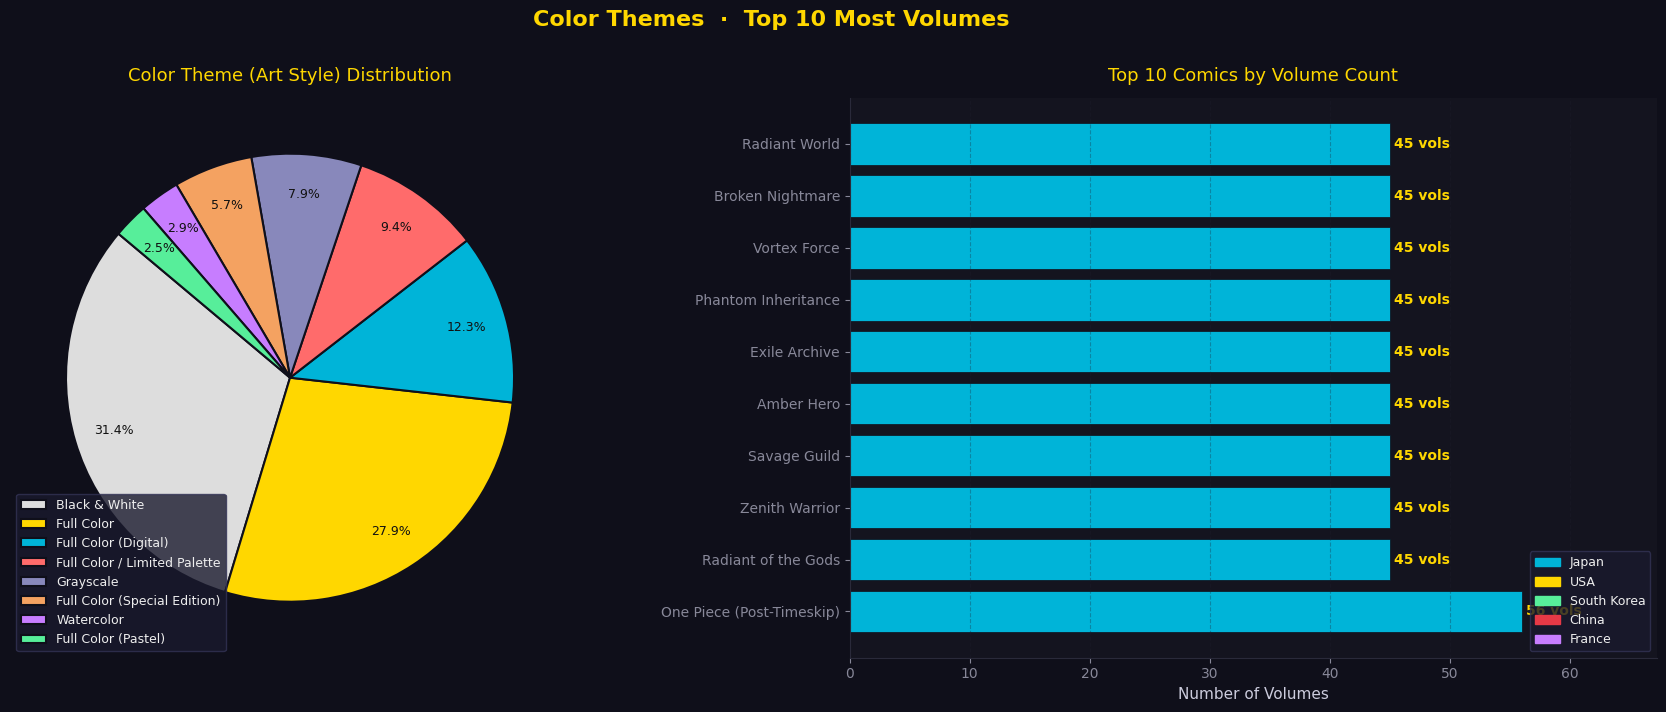

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Color Themes  ·  Top 10 Most Volumes',
             fontsize=16, fontweight='bold', color='#FFD700', y=1.01)

# ── LEFT: Color theme breakdown ────────────────────────────────────────────
ax1 = axes[0]
theme_counts = df['Theme (Color Style)'].value_counts()
theme_palette = {
    'Black & White':             '#DDDDDD',
    'Full Color':                '#FFD700',
    'Full Color (Digital)':      '#00B4D8',
    'Grayscale':                 '#8888BB',
    'Full Color / Limited Palette': '#FF6B6B',
    'Full Color (Special Edition)': '#F4A261',
    'Watercolor':                '#C77DFF',
    'Full Color (Pastel)':       '#57EE9A',
}
tc = [theme_palette.get(t, '#888888') for t in theme_counts.index]
wedges, texts, autotexts = ax1.pie(
    theme_counts.values, labels=None,
    colors=tc, autopct='%1.1f%%',
    startangle=140, pctdistance=0.82,
    wedgeprops={'edgecolor':'#0f0f1a','linewidth':1.5}
)
for at in autotexts: at.set_fontsize(9); at.set_color('#111')
ax1.legend(wedges, theme_counts.index, loc='lower left',
           fontsize=9, facecolor='#1a1a2e', edgecolor='#333355')
ax1.set_title('Color Theme (Art Style) Distribution', fontsize=13, color='#FFD700', pad=12)

# ── RIGHT: Top 10 Most Volumes ─────────────────────────────────────────────
ax2 = axes[1]
top_vol = df.nlargest(10, 'Volume Count')[['Title','Volume Count','Country of Origin']].reset_index(drop=True)
vol_colors = [colors_map.get(c,'#FF6B6B') for c in top_vol['Country of Origin']]
bars = ax2.barh(range(len(top_vol)), top_vol['Volume Count'],
                color=vol_colors, edgecolor='#0f0f1a', linewidth=0.5)
ax2.set_yticks(range(len(top_vol)))
ax2.set_yticklabels([t[:28] for t in top_vol['Title']], fontsize=10)
for bar, val in zip(bars, top_vol['Volume Count']):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val} vols', va='center', fontsize=10, color='#FFD700', fontweight='bold')
ax2.set_title('Top 10 Comics by Volume Count', fontsize=13, color='#FFD700', pad=12)
ax2.set_xlabel('Number of Volumes', fontsize=11)
ax2.set_xlim(0, top_vol['Volume Count'].max() * 1.2)
ax2.grid(axis='x', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
legend_patches2 = [mpatches.Patch(color=v, label=k) for k,v in colors_map.items()]
ax2.legend(handles=legend_patches2, loc='lower right', fontsize=9,
           facecolor='#1a1a2e', edgecolor='#333355')

plt.tight_layout()
plt.savefig('section4_themes_volumes.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


#### Section 5 - Award Winners & Topo by Region

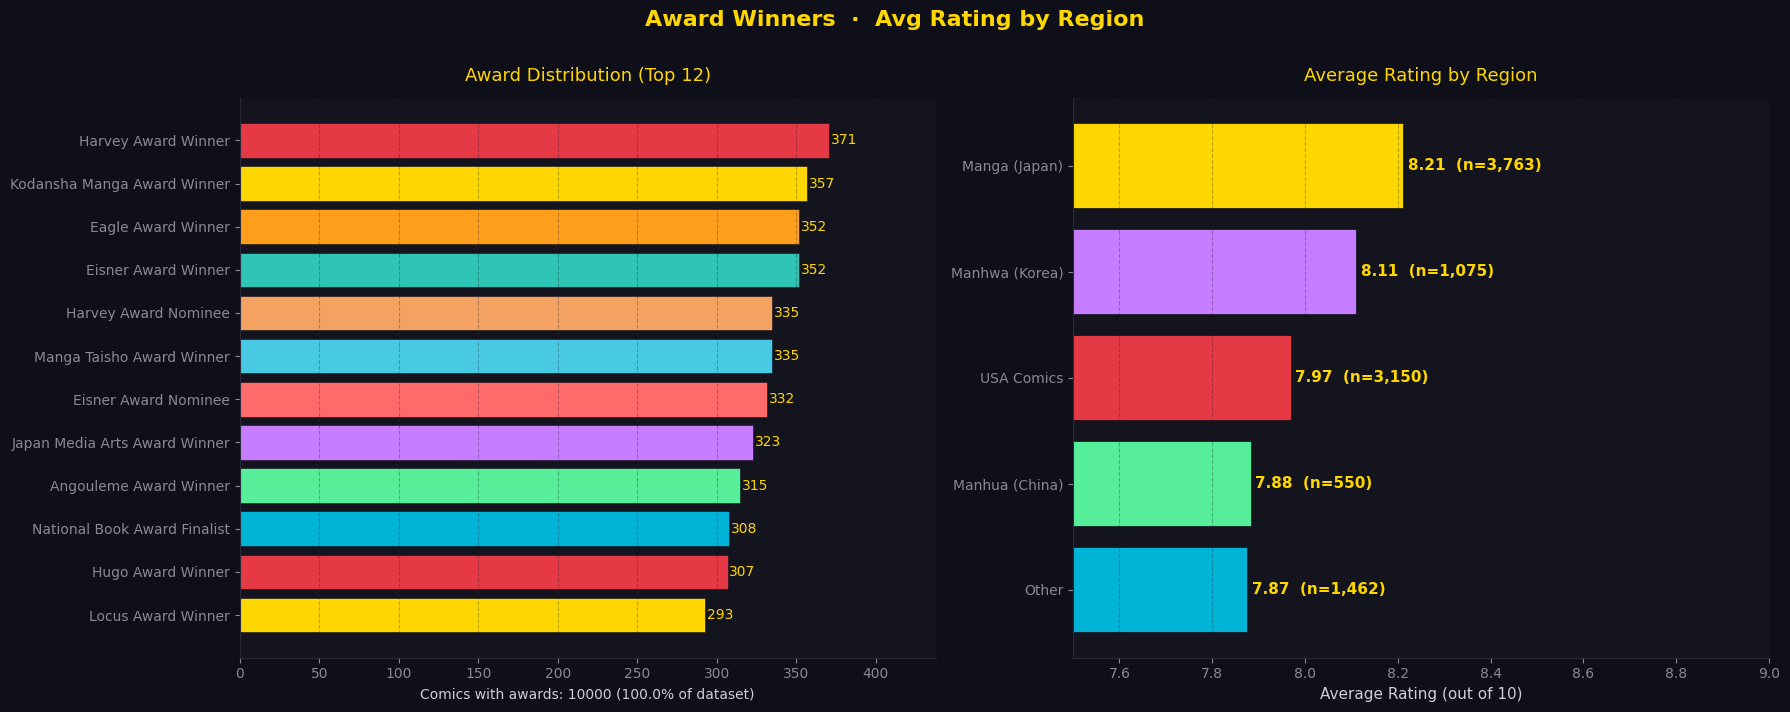

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Award Winners  ·  Avg Rating by Region',
             fontsize=16, fontweight='bold', color='#FFD700', y=1.01)

# ── LEFT: Award distribution ───────────────────────────────────────────────
ax1 = axes[0]
award_counts = df[df['Awards'] != 'None']['Awards'].value_counts().head(12)
bars = ax1.barh(award_counts.index[::-1], award_counts.values[::-1],
                color=COLORS[:len(award_counts)], edgecolor='#0f0f1a', linewidth=0.4)
for bar, val in zip(bars, award_counts.values[::-1]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10, color='#FFD700')
ax1.set_title('Award Distribution (Top 12)', fontsize=13, color='#FFD700', pad=12)
ax1.set_xlabel('Number of Comics', fontsize=11)
ax1.set_xlim(0, award_counts.max() * 1.18)
ax1.grid(axis='x', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
total_awarded = len(df[df['Awards'] != 'None'])
ax1.set_xlabel(f'Comics with awards: {total_awarded} ({total_awarded/len(df)*100:.1f}% of dataset)', fontsize=10)

# ── RIGHT: Avg rating by region ────────────────────────────────────────────
ax2 = axes[1]
region_rating = df.groupby('Region')['Rating (out of 10)'].agg(['mean','count']).sort_values('mean', ascending=True)
rc = ['#00B4D8','#57EE9A','#E63946','#C77DFF','#FFD700']
bars2 = ax2.barh(region_rating.index, region_rating['mean'],
                 color=rc[:len(region_rating)], edgecolor='#0f0f1a', linewidth=0.5)
for bar, (mean_val, cnt) in zip(bars2, region_rating.values):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{mean_val:.2f}  (n={int(cnt):,})', va='center', fontsize=11,
             color='#FFD700', fontweight='bold')
ax2.set_title('Average Rating by Region', fontsize=13, color='#FFD700', pad=12)
ax2.set_xlabel('Average Rating (out of 10)', fontsize=11)
ax2.set_xlim(7.5, 9.0)
ax2.grid(axis='x', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('section5_awards_regions.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

#### Section 6 - Final Summary Dashboard

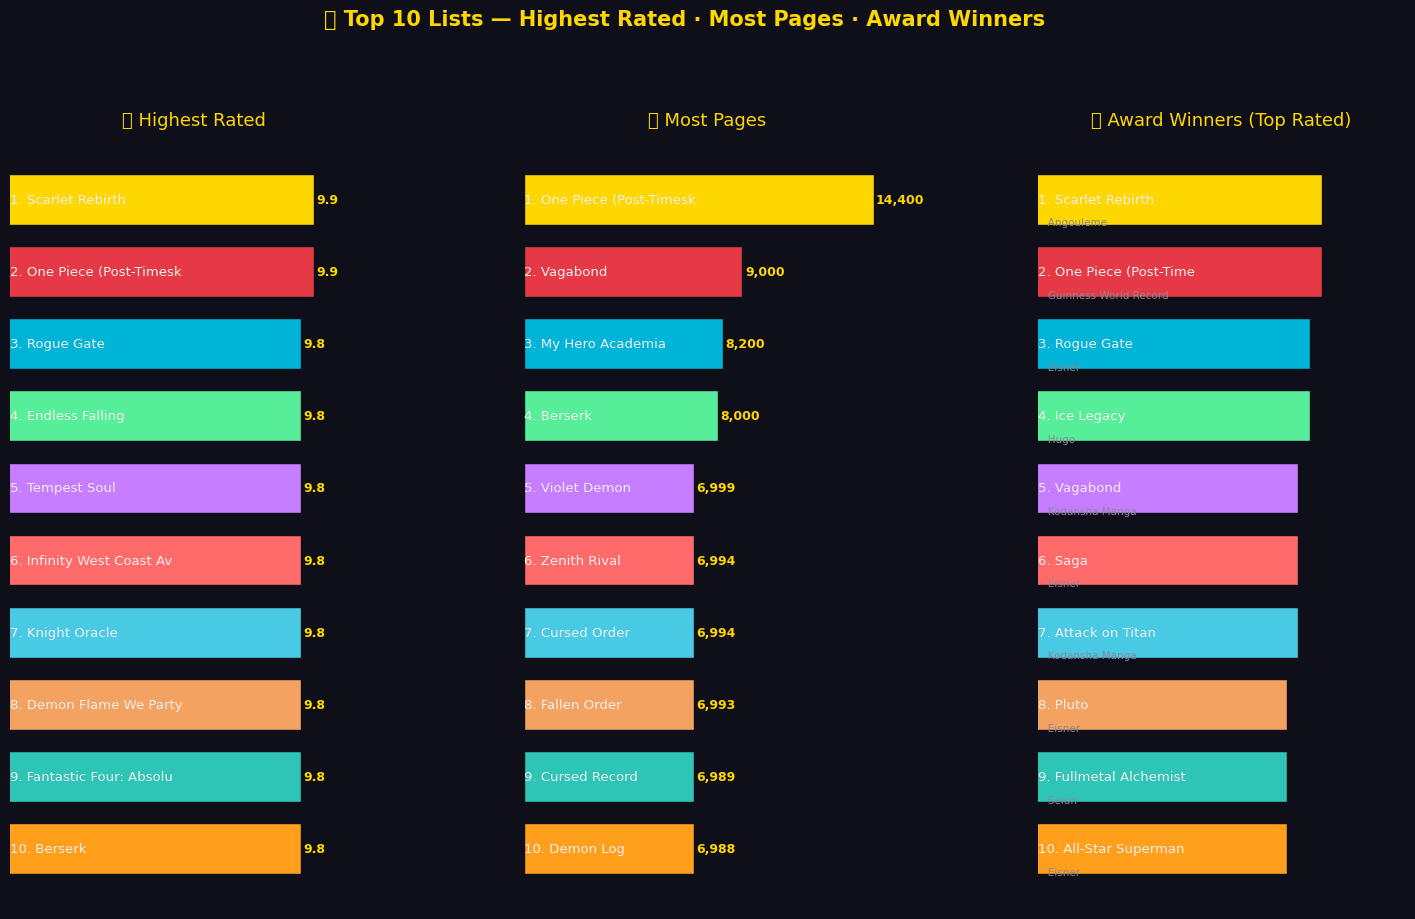


✅ All charts generated!
📊 Dataset analysis complete.


In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- FIX: Pre-fill any empty Awards to avoid 'float' errors ---
df['Awards'] = df['Awards'].fillna('None')

fig = plt.figure(figsize=(18, 10))
fig.suptitle('🏆 Top 10 Lists — Highest Rated · Most Pages · Award Winners',
             fontsize=15, fontweight='bold', color='#FFD700', y=1.01)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

# ── TOP 10 HIGHEST RATED ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
top_rated = df.nlargest(10, 'Rating (out of 10)')[['Title','Rating (out of 10)']]
for i, (_, row) in enumerate(top_rated.iterrows()):
    y_pos = 9 - i
    ax1.barh(y_pos, row['Rating (out of 10)'], color=COLORS[i],
             height=0.7, edgecolor='#0f0f1a')
    ax1.text(7.5, y_pos, f"{i+1}. {row['Title'][:22]}", va='center',
             fontsize=9.5, color='#eeeeee')
    ax1.text(row['Rating (out of 10)']+0.02, y_pos, f"{row['Rating (out of 10)']}",
             va='center', fontsize=9, color='#FFD700', fontweight='bold')
ax1.set_xlim(7.5, 10.4)
ax1.set_title('⭐ Highest Rated', fontsize=13, color='#FFD700', pad=10)
ax1.axis('off')

# ── TOP 10 MOST PAGES ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
top_pages = df.nlargest(10, 'Page Count')[['Title','Page Count']]
for i, (_, row) in enumerate(top_pages.iterrows()):
    y_pos = 9 - i
    ax2.barh(y_pos, row['Page Count'], color=COLORS[i],
             height=0.7, edgecolor='#0f0f1a')
    ax2.text(0, y_pos, f"{i+1}. {row['Title'][:22]}", va='center',
             fontsize=9.5, color='#eeeeee')
    ax2.text(row['Page Count']+100, y_pos, f"{int(row['Page Count']):,}",
             va='center', fontsize=9, color='#FFD700', fontweight='bold')
ax2.set_title('📖 Most Pages', fontsize=13, color='#FFD700', pad=10)
ax2.axis('off')

# ── TOP AWARD WINNERS ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
# Filter for actual winners, then take top 10 by rating
award_df = df[df['Awards'] != 'None'].nlargest(10, 'Rating (out of 10)')[['Title','Awards','Rating (out of 10)']]

for i, (_, row) in enumerate(award_df.iterrows()):
    y_pos = 9 - i
    ax3.barh(y_pos, row['Rating (out of 10)'], color=COLORS[i],
             height=0.7, edgecolor='#0f0f1a')
    ax3.text(7.5, y_pos, f"{i+1}. {row['Title'][:20]}", va='center',
             fontsize=9.5, color='#eeeeee')

    # SAFE REPLACE: Convert to string first to prevent 'float' AttributeError
    award_text = str(row['Awards'])
    award_short = award_text.replace(' Award Winner','').replace(' Award Nominee','')

    ax3.text(7.5, y_pos - 0.32, f"   {award_short[:25]}", va='center',
             fontsize=7.5, color='#888899')

ax3.set_xlim(7.5, 10.6)
ax3.set_title('🏆 Award Winners (Top Rated)', fontsize=13, color='#FFD700', pad=10)
ax3.axis('off')

plt.tight_layout()
plt.savefig('section6_top10_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print('\n✅ All charts generated!')
print('📊 Dataset analysis complete.')